# Survival Analysis
This notebook processes the interpolated measurements to obtain survival probabilities for inverse probability weighting (IPW) of the delta scores. Furthermore, it contains visualizations of the time-varying CoxPH and its results.

## Modules

In [ ]:
import json
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt

from lifelines import CoxTimeVaryingFitter, KaplanMeierFitter
from scipy.interpolate import interp1d
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LogisticRegression

from longitudinal_arm_swing.constants import *

pd.set_option('display.max_columns', 500)

## Constants

In [82]:
filter_type = 'filtered'
measures = ['median', '95p']
segment_lengths = ['0_20', '20_inf']

path_measures = os.path.join(BASE_PATH, 'measures', f'{filter_type}_gait')

pd_med_id_filename = 'pd_med_ids.txt'
pd_no_med_id_filename = 'pd_no_med_ids.txt'
ids_remaining_after_exclusions_filename = 'ids_remaining_after_exclusions.json'
aff_side_ids_filename = 'affected_side_ids.json'

min_lag = 6

## Functions

In [ ]:
def add_lag_features(df, measure, lag, time_lag_var, time_lag_mult):
    if lag == 'max':
        past = df.groupby('id')[measure].transform('first')
        lag_mult = lag
    else:
        past = df.groupby('id')[measure].shift(lag)
        lag_mult = lag * time_lag_mult

    # Absolute value
    df[f'{measure}_val_{lag_mult}_{time_lag_var}_lag'] = past
    
    # Absolute delta
    df[f'{measure}_delta_{lag_mult}_{time_lag_var}_lag'] = df[measure] - past
    
    # Relative delta (% change)
    df[f'{measure}_delta_pct_{lag_mult}_{time_lag_var}_lag'] = df[f'{measure}_delta_{lag_mult}_{time_lag_var}_lag'] / past * 100

    return df

## Load

In [ ]:
# Load the non-interpolated values
signal_vals = {}
for measure in measures:
    signal_vals[measure] = {}
    for length in segment_lengths:
        signal_vals[measure][length] = pd.read_csv(os.path.join(path_measures, length, f'pd_signal_interp_{measure}_range_of_motion.csv'))

with open(os.path.join(path_measures, '20_inf', 'pd_med_ids.txt'), 'r') as f:
    pd_med_ids = f.read().splitlines()

with open(os.path.join(path_measures, '20_inf', 'pd_no_med_ids.txt'), 'r') as f:
    pd_no_med_ids = f.read().splitlines()

with open(os.path.join(PATH_IDS, ids_remaining_after_exclusions_filename), 'r') as f:
    ids_remaining_after_exclusions = json.load(f)

with open(os.path.join(PATH_IDS, aff_side_ids_filename), 'r') as f:
    aff_side_ids = json.load(f)

with open(os.path.join(PATH_IDS, 'med_info_ids.json'), 'r') as f:
    med_info_ids = json.load(f)

with open(os.path.join(PATH_IDS, 'excluded_ids_by_category.json'), 'r') as f:
    excluded_ids_by_category = json.load(f)

with open(os.path.join(PATH_IDS, 'ids_bins.json'), 'r') as f:
    ids_bins = json.load(f)

start_med_week_dict = {
    'ppp': pd.read_csv(os.path.join(PATH_CLINICAL_DATA, 'ppp', PPP_START_MED_FILENAME)),
    'denovo': pd.read_csv(os.path.join(PATH_CLINICAL_DATA, 'denovo', DENOVO_START_MED_WEEK_FILENAME))
}

df_measures_inclusion = pd.read_parquet(os.path.join(BASE_PATH, 'measures', 'digital_measures.parquet'))

## Prepare data

In [85]:
signal_ids = pd_med_ids + pd_no_med_ids

start_med_ids = list(set([id for id in signal_ids if id in med_info_ids['groups']['start_med']['denovo'] + med_info_ids['groups']['start_med']['ppp']]))

for measure in ['median', '95p']:
    pd_med_ids_remaining = pd_med_ids.copy()
    pd_no_med_ids_remaining = pd_no_med_ids.copy()

    for length in segment_lengths:
        signal_vals[measure][length]['id'] = signal_ids

    # Drop the medicated parts of participants that start medication (i.e., the first row)
    for subject in start_med_ids:
        subject_idx = signal_vals[measure]['20_inf'].index[signal_vals[measure]['20_inf']['id'] == subject].tolist()

        # Drop the first row (medicated part) or if the only row is of the medicated ids
        if len(subject_idx) == 2 or subject_idx[0] < len(pd_med_ids_remaining):
            drop_idx = subject_idx[0]
        else:
            continue

        for length in segment_lengths:
            # Drop the medicated part of the participant
            signal_vals[measure][length] = signal_vals[measure][length].drop(drop_idx)

        pd_med_ids_remaining = [id for id in pd_med_ids_remaining if id != subject]

    # Drop ids without data
    ids_with_all_nan = signal_vals[measure]['20_inf'][signal_vals[measure]['20_inf'].drop(columns=['id']).apply(lambda x: x.isna()).all(axis=1)]['id'].values
    for length in segment_lengths:
        signal_vals[measure][length] = signal_vals[measure][length].loc[~signal_vals[measure][length]['id'].isin(ids_with_all_nan)].reset_index(drop=True)
        
pd_med_ids_remaining = [id for id in pd_med_ids_remaining if id not in ids_with_all_nan]
pd_no_med_ids_remaining = [id for id in pd_no_med_ids_remaining if id not in ids_with_all_nan]

In [86]:
# Create a dictionary with:
# - The week of censoring
# - The reason for censoring:
#     - Medicated: (1) no clinical data, (2) walking aid, (3) dyskinesia, (4) watch side switched, (5) study dropout
#     - Non-medicated: reasons above, plus (6) start medication

ids_bins_datasets = ['ppp', 'denovo']
censoring_dict = {}

remaining_signal_ids = signal_vals['median']['20_inf']['id'].values

for subject in remaining_signal_ids:
    min_censoring_week = 102
    min_censoring_reason = 'study_finished'
    for dataset in ids_bins_datasets:
        for clinical_colname_check in ['walking_aid', 'at_least_significant_dyskinesia']:
            visit_1 = ids_bins[dataset].get(f'{clinical_colname_check}_visit_1', [])
            visit_2 = ids_bins[dataset].get(f'{clinical_colname_check}_visit_2', [])
            visit_3 = ids_bins[dataset].get(f'{clinical_colname_check}_visit_3', [])

            if subject in visit_2 and subject not in visit_1 and 2 < min_censoring_week:
                min_censoring_week = 2
                min_censoring_reason = clinical_colname_check

            if subject in visit_3 and subject not in visit_2 and 52 < min_censoring_week:
                min_censoring_week = 52
                min_censoring_reason = clinical_colname_check

        if subject in ids_bins[dataset]['watch_side_switched_visits_1_2'] and 2 < min_censoring_week:
            min_censoring_week = 2
            min_censoring_reason = 'watch_side_switched'
            
        if subject in ids_bins[dataset]['watch_side_switched_visits_2_3'] and 52 < min_censoring_week:
            min_censoring_week = 52
            min_censoring_reason = 'watch_side_switched'

        if subject in start_med_ids and subject in start_med_week_dict[dataset]['ID'].values:
            start_med_week = start_med_week_dict[dataset].loc[start_med_week_dict[dataset]['ID'] == subject, 'StartWeek'].values[0]

            if start_med_week < min_censoring_week:
                min_censoring_week = start_med_week
                min_censoring_reason = 'start_medication'

    series = signal_vals['median']['20_inf'].loc[signal_vals['median']['20_inf']['id'] == subject].squeeze().drop(labels='id')
    final_week = int(series.index[series.notna()][-1].strip('week'))

    if final_week < min_censoring_week - min_lag:  # Due to the lag of N weeks we can miss some data
        min_censoring_week = final_week
        min_censoring_reason = 'no_sensor_data'

    censoring_dict[subject] = {
        'first_censored_week': int(min_censoring_week),
        'censoring_reason': min_censoring_reason,
    }

with open(os.path.join(path_measures, 'censoring_dict.json'), 'w') as f:
    json.dump(censoring_dict, f, indent=4)

We create a bi-weekly model for med and no-med, and a yearly model for med.

In [ ]:
event_censoring_reasons = ['start_medication', 'walking_aid', 'at_least_significant_dyskinesia']
nonevent_censoring_reasons = ['watch_side_switched', 'no_sensor_data', 'no_clinical_data']

survival_params = {
    'lags': [1, 2, 3, 4, 5, 'max'],
    'time_lag_var': 'week',
    'time_lag_mult': 2,
}

final_dfs = {}
for med_status in ['med', 'no_med']:
    final_dfs[med_status] = {}
    if med_status == 'med':
        idx_min = 0
        idx_max = len(pd_med_ids_remaining) - 1
    else:
        idx_min = len(pd_med_ids_remaining)
        idx_max = len(signal_vals[measures[0]][segment_lengths[0]])

    for i, measure in enumerate(measures):
        for j, segment_length in enumerate(segment_lengths):
            val = signal_vals[measure][segment_length].loc[idx_min : idx_max].melt(
                id_vars='id', var_name='week', value_name=measure
            ).rename(columns={measure: f'{measure}_{segment_length}'})

            if i == 0 and j == 0:
                df_coxph = val
            else:
                df_coxph = df_coxph.merge(val, on=['id', 'week'])

    df_coxph['week_num'] = df_coxph['week'].str.extract(r'(\d+)').astype(int)
    df_coxph['first_censored_week'] = df_coxph['id'].map(lambda x: censoring_dict.get(x, {}).get('first_censored_week', None))
    df_coxph['censoring_reason'] = df_coxph['id'].map(lambda x: censoring_dict.get(x, {}).get('censoring_reason', None))

    # Drop rows post-censoring
    df_coxph = df_coxph.loc[(df_coxph['week_num'] < df_coxph['first_censored_week']) & (df_coxph['week_num'] <= 100)]   # We current set the max at week 100

    # Determine IDs with event censoring
    event_ids = df_coxph.loc[df_coxph['censoring_reason'].isin(event_censoring_reasons), 'id'].unique()

    final_dfs[med_status] = {}
    df_model = df_coxph.sort_values(['id', 'week_num']).copy()
    for measure in measures:
        for length in segment_lengths:
            for lag in survival_params['lags']:
                df_model = add_lag_features(df_model, f'{measure}_{length}', lag, survival_params['time_lag_var'], survival_params['time_lag_mult'])

    # Mark event = 1 for ids with censoring event
    df_model['event'] = 0  

    idx_max_week = df_model.loc[df_model['id'].isin(event_ids)].groupby('id')['week_num'].idxmax()
    df_model.loc[idx_max_week, 'event'] = 1

    # Since time-varying covariates has structure (start, stop], the measure at T = t should have start = t - 2, stop = t.
    df_model['start'] = df_model['week_num'] - 2

    df_model['stop'] = df_model['week_num']  # biweekly intervals (2 weeks)

    final_dfs[med_status]['model'] = df_model

## Examine data

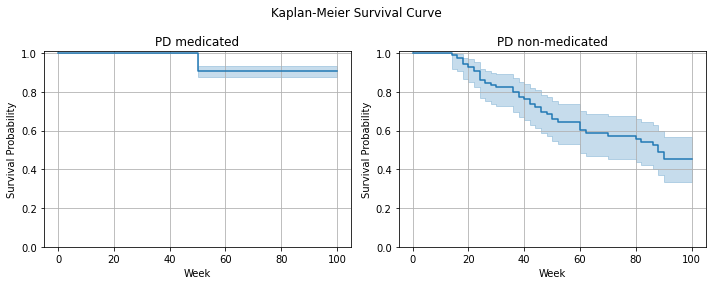

In [88]:
fig, ax = plt.subplots(ncols=2, figsize=(10, 4))

kmf = KaplanMeierFitter()

for j, med_status in enumerate(['med', 'no_med']):
    km_df = (
        final_dfs[med_status]['model']
        .groupby('id')
        .agg(
            start=('week_num', 'min'),
            stop=('stop', 'max'),
            event=('event', 'max')  # Assumes only one event per person
        )
        .reset_index()
    )

    # Fit and plot
    kmf.fit(
        durations=km_df['stop'],
        event_observed=km_df['event'],
        label=med_status
    )
    kmf.plot_survival_function(ax=ax[j])

    ax[j].set_ylim([0, 1.01])

    ax[j].grid()
    ax[j].set_xlabel('Week')
    ax[j].set_ylabel('Survival Probability')

    ax[j].legend().remove()

ax[0].set_title('PD medicated')
ax[1].set_title('PD non-medicated')

fig.suptitle('Kaplan-Meier Survival Curve')

plt.tight_layout()
plt.show()

## Analysis

* Non-medicated group: we expect the decision to start medication to be determined based on the perceived arm swing of a participant, in particular the change in RoM. Hence, look at a few weeks lag.
* Medicated group: different from the non-medicated group, we expect this group to be based on the **current** value.

#### Time-varying CoxPH

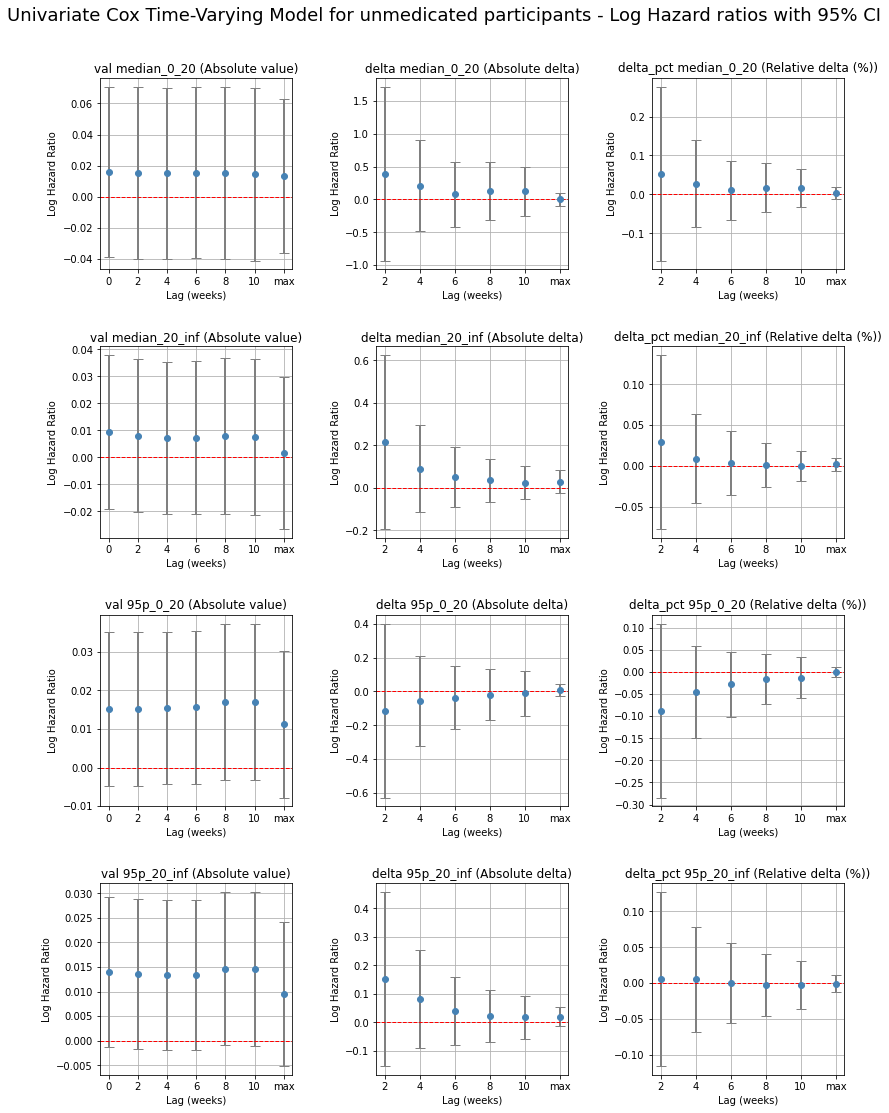

In [ ]:
lags = np.arange(0, 10 + 1, 2).tolist() + ['max']
med_state = 'med'

stats = ['val', 'delta', 'delta_pct']
df_plot = final_dfs[med_state]['model']

measure_x_length = [f'{measure}_{segment_length}' for measure in measures for segment_length in segment_lengths]

fig, ax = plt.subplots(nrows=len(measure_x_length), ncols=len(stats), figsize=(len(stats) * 4, len(measure_x_length) * 4))

for i, measure in enumerate(measure_x_length):
    coefs = {}
    for j, stat in enumerate(stats):
        coefs[stat] = {}
        for lag in lags:
            if lag == 0 and stat == 'val':
                var = measure
            elif lag != 0:
                var = f'{measure}_{stat}_{lag}_week_lag'
            else:
                continue

            df_model_ctv = df_plot[['id', 'start', 'stop', 'event', var]].dropna()

            ctv = CoxTimeVaryingFitter()
            ctv.fit(
                df_model_ctv,
                id_col='id',
                event_col='event',
                start_col='start',
                stop_col='stop',
            )

            coefs[stat][lag] = {
                'coef': ctv.hazard_ratios_.values[0], # hazard ratio
                'lower_ci': ctv.confidence_intervals_.values[0][0],
                'upper_ci': ctv.confidence_intervals_.values[0][1],
            }

        if stat != 'val':
            lag_vals = lags[1:].copy()
        else:
            lag_vals = lags.copy()

        coef_vals = [np.log(coefs[stat][lag]['coef']) for lag in lag_vals]
        lower_cis = [coefs[stat][lag]['lower_ci'] for lag in lag_vals]
        upper_cis = [coefs[stat][lag]['upper_ci'] for lag in lag_vals]

        error_bars = [
            [hr - lower, upper - hr]
            for hr, lower, upper in zip(coef_vals, lower_cis, upper_cis)
        ]
        error_bars = list(zip(*error_bars))

        lag_vals[-1] = lag_vals[-2] + (lag_vals[-2] - lag_vals[-3])

        ax[i, j].errorbar(
            lag_vals,
            coef_vals,
            yerr=error_bars,
            fmt='o',
            capsize=5,
            color='steelblue',
            ecolor='gray',
            elinewidth=2,
        )

        if j == 0:
            metric_label = 'Absolute value'
        elif j == 1:
            metric_label = 'Absolute delta'
        else:
            metric_label = 'Relative delta (%)'

        lag_vals_labels = lag_vals.copy()
        lag_vals_labels[-1] = 'max'

        ax[i, j].axhline(0, color='red', linestyle='--', linewidth=1)
        ax[i, j].set_xticks(lag_vals, lag_vals_labels)
        ax[i, j].grid(True)
        ax[i, j].set_xlabel('Lag (weeks)')

        ax[i, j].set_ylabel('Log Hazard Ratio')
        ax[i, j].set_title(f'{stat} {measure} ({metric_label})')
    
plt.suptitle(f'Univariate Cox Time-Varying Model for unmedicated participants - Log Hazard ratios with 95% CI', fontsize=18)

plt.tight_layout(pad=3)
plt.show()

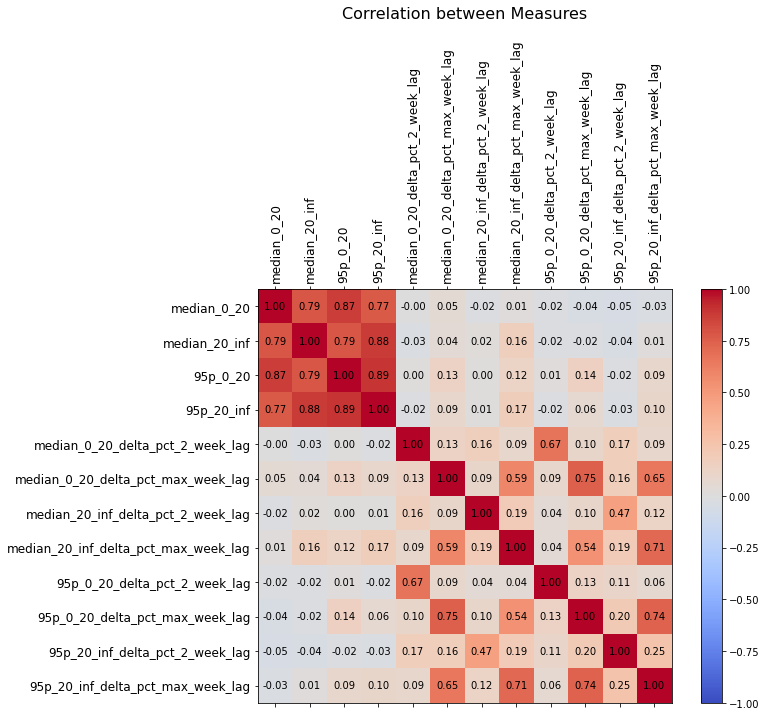

In [ ]:
measures_corr = ['median_0_20', 'median_20_inf', '95p_0_20', '95p_20_inf']
delta_lag_weeks = [2, 'max']

lag_measures = [f'{measure}_delta_pct_{lag}_week_lag' for measure in measures_corr for lag in delta_lag_weeks] 
all_vars = measures_corr + lag_measures

corr_df = final_dfs[med_state]['model'][all_vars].dropna().corr()

fig, ax = plt.subplots(figsize=(12, 10))
cax = ax.matshow(corr_df, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(cax)

ax.set_xticks(range(len(corr_df.columns)))
ax.set_yticks(range(len(corr_df.index)))
ax.set_xticklabels(corr_df.columns, rotation=90, fontsize=12)
ax.set_yticklabels(corr_df.index, fontsize=12)

for (i, j), val in np.ndenumerate(corr_df.values):
    ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=10, color='black')

ax.set_title('Correlation between Measures', fontsize=16, pad=20)
plt.tight_layout()
plt.show()


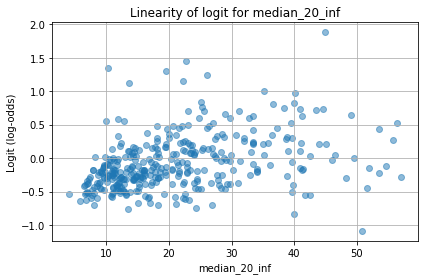

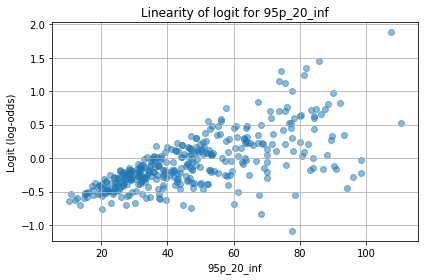

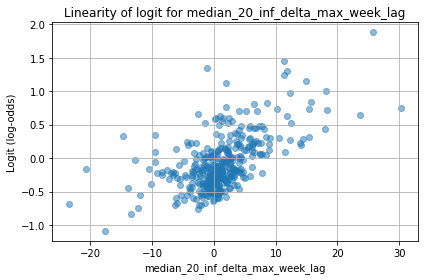

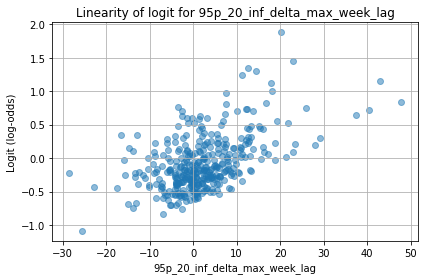

In [ ]:
included_covariates = ['median_20_inf', '95p_20_inf', 'median_20_inf_delta_max_week_lag', '95p_20_inf_delta_max_week_lag']

if med_state == 'med':
    df_logreg = df_plot[['id', 'start', 'stop', 'event'] + included_covariates].dropna().rename(columns={'stop': 'week'}).copy()

    df_logreg_train = df_logreg.loc[df_logreg['week'] == 50].copy()

    X = df_logreg_train[included_covariates].values
    y = df_logreg_train['event'].astype(int)

    polynomial_degree = 1  
    poly = PolynomialFeatures(degree=polynomial_degree, include_bias=False)
    X_poly = poly.fit_transform(X)
    covariate_names = poly.get_feature_names_out(included_covariates)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_poly)

    logreg = LogisticRegression(class_weight='balanced', solver='lbfgs', max_iter=1000) 
    logreg.fit(X_scaled, y)

    y_pred = logreg.predict_proba(X_scaled)[:, 1]
    df_logreg_train['survival_prob'] = 1 - y_pred

    df_logreg = df_logreg.loc[df_logreg['week'] >= 50].merge(df_logreg_train[['id', 'survival_prob']], on=['id'], how='left')

    df_logreg[['id', 'week', 'survival_prob']].to_csv(os.path.join(path_measures, f'survival_probabilities_{med_state}.csv'), index=False)

    for i, covariate in enumerate(covariate_names):
        plt.figure(figsize=(6, 4))
        plt.scatter(X_poly[:, i], np.log(y_pred / (1 - y_pred)), alpha=0.5)
        plt.title(f'Linearity of logit for {covariate}')
        plt.xlabel(covariate)
        plt.ylabel('Logit (log-odds)')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

else:
    df_coxph = df_plot[['id', 'start', 'stop', 'event', 'censoring_reason', 'first_censored_week'] + included_covariates].copy().dropna().reset_index(drop=True)
    df_ctv = df_coxph.drop(columns=['censoring_reason', 'first_censored_week'])

    ctv = CoxTimeVaryingFitter()
    ctv.fit(
        df_ctv,
        id_col='id',
        event_col='event',
        start_col='start',
        stop_col='stop',
    )

    ctv.print_summary()

    df_coxph['linear_predictor'] = ctv.predict_partial_hazard(df_coxph[included_covariates])

    event_times = ctv.baseline_cumulative_hazard_.index.values
    baseline_hazard_values = ctv.baseline_cumulative_hazard_.iloc[:, 0].values

    hazard_interp_fn = interp1d(event_times, baseline_hazard_values, kind='previous', 
                                fill_value=(0.0, baseline_hazard_values[-1]), bounds_error=False)

    all_ctv_weeks = df_coxph['stop'].unique()
    baseline_hazard_full = hazard_interp_fn(all_ctv_weeks)
    map_baseline_hazard = dict(zip(all_ctv_weeks, baseline_hazard_full))

    df_coxph['baseline_cumulative_hazard'] = df_coxph['stop'].map(map_baseline_hazard)
    df_coxph['cumulative_hazard'] = df_coxph['baseline_cumulative_hazard'] * df_coxph['linear_predictor']

    df_coxph['survival_prob'] = np.exp(-df_coxph['cumulative_hazard'])

    df_coxph[['id', 'stop', 'survival_prob']].rename(columns={'stop': 'week'}).to_csv(os.path.join(path_measures, f'survival_probabilities_{med_state}.csv'), index=False)